In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error, mean_absolute_percentage_error

import time
import xgboost as xgb

In [2]:
# 1. Chargement et Tri
df = pd.read_parquet('data\processed_windspeed.parquet')
df['horodatage_référence'] = pd.to_datetime(df['horodatage_référence'], dayfirst=True)
df = df.sort_values('horodatage_référence').reset_index(drop=True)

# 2. Gestion des NaN (Interpolation linéaire : relie les points logiquement en comblant les trous)
# On ne traite que les colonnes numériques
cols_num = df.select_dtypes(include=[np.number]).columns
df[cols_num] = df[cols_num].interpolate(method='linear').fillna(method='bfill')

# 3. Feature Engineering (Heure, Mois et Retards temporels)
df['hour'] = df['horodatage_référence'].dt.hour
df['month'] = df['horodatage_référence'].dt.month

# On crée des lags : le vent à T-10min et T-20min
# ? Les lags permettent d'éviter pour les premières lignes des erreurs car le programme ne trouve pas de données avant dans le temps
target = 'vitesse_vent_moyenne_10min_kmh'
df['vent_10min_avant'] = df[target].shift(1) # ? décalage des données de la colonne vers 1 en bas
df['vent_20min_avant'] = df[target].shift(2) # ? décalage des données de la colonne vers 2 en bas
df['vent_30min_avant'] = df[target].shift(3) # ? décalage des données de la colonne vers 3 en bas
df['vent_40min_avant'] = df[target].shift(4) # ? décalage des données de la colonne vers 4 en bas
df['vent_50min_avant'] = df[target].shift(5) # ? décalage des données de la colonne vers 5 en bas
df['vent_60min_avant'] = df[target].shift(6) # ? décalage des données de la colonne vers 6 en bas

# On supprime les lignes du début devenues NaN à cause du décalage (shift)
df = df.dropna(subset=['vent_10min_avant', 
                       'vent_20min_avant', 
                       'vent_30min_avant', 
                       'vent_40min_avant', 
                       'vent_50min_avant', 
                       'vent_60min_avant'])

### Choix des variables + Split

In [5]:
# Choix des variables explicatives (Features)
# On évite de mettre les autres colonnes de vent "moyenne" qui donneraient la réponse au modèle
features = [
    'vent_10min_avant', 
    'vent_20min_avant',
    'vent_30min_avant', 
    'vent_40min_avant', 
    'vent_50min_avant', 
    'vent_60min_avant',
    'hour', 
    'month',
    'pression_barométrique_qfe_valeur_instantanée',
    'humidité_relative_air_2m_valeur_instantanée',
    'précipitations_somme_10min',
    'température_air_2m_valeur_instantanée',
    'rafale_3s_maximum_kmh'
]

# On s'assure que les colonnes existent avant de split
features = [f for f in features if f in df.columns]

# Split chronologique (le passé sert d'entrainement)
split_idx = int(len(df) * 0.8) # longueur du df - 80% sont gardés pour le train et 20% pour le test
train_df = df.iloc[:split_idx] # on prend tout ce qui avant l'index
test_df = df.iloc[split_idx:] # on prend tout ce qui a après l'index

X_train, y_train = train_df[features], train_df[target]
X_test, y_test = test_df[features], test_df[target]

### Création du pipeline + entrainement + prédiction + résultats

In [20]:
# 1. Configuration du modèle pour GPU
model = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=10, 
    tree_method='hist', 
    device='cuda',
    random_state=42
)

print(f"🚀 Lancement de l'entraînement GPU sur {len(X_train)} lignes...")

start_time = time.time() # on déclenche le chrono

model.fit(X_train, y_train)

# 3. Calcul du temps
end_time = time.time()
duree = end_time - start_time

print(f"✅ Terminé en {duree:.2f} secondes (soit {duree/60:.2f} minutes)")

# Prédiction
y_pred = model.predict(X_test)

# ÉVALUATION AVANCÉE (Correction du MAPE pour éviter l'infini)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

# Pour le MAPE, on filtre les valeurs réelles > 0.5 km/h pour éviter la division par zéro
mask = y_test > 0.5
mape_clean = mean_absolute_percentage_error(y_test[mask], y_pred[mask])

print(f"--- RÉSULTATS ---")
print(f"Score R² : {r2:.4f}")
print(f"Erreur moyenne (MAE) : {mae:.2f} km/h")
print(f"RMSE : {rmse:.2f} km/h (Sensible aux grosses erreurs)")
print(f"MAPE : {mape_clean:.2%} (Erreur relative moyenne hors calme plat)")

🚀 Lancement de l'entraînement GPU sur 909312 lignes...
✅ Terminé en 10.91 secondes (soit 0.18 minutes)
--- RÉSULTATS ---
Score R² : 0.9415
Erreur moyenne (MAE) : 1.04 km/h
RMSE : 1.66 km/h (Sensible aux grosses erreurs)
MAPE : 15.09% (Erreur relative moyenne hors calme plat)


### Visualisations / Graphiques

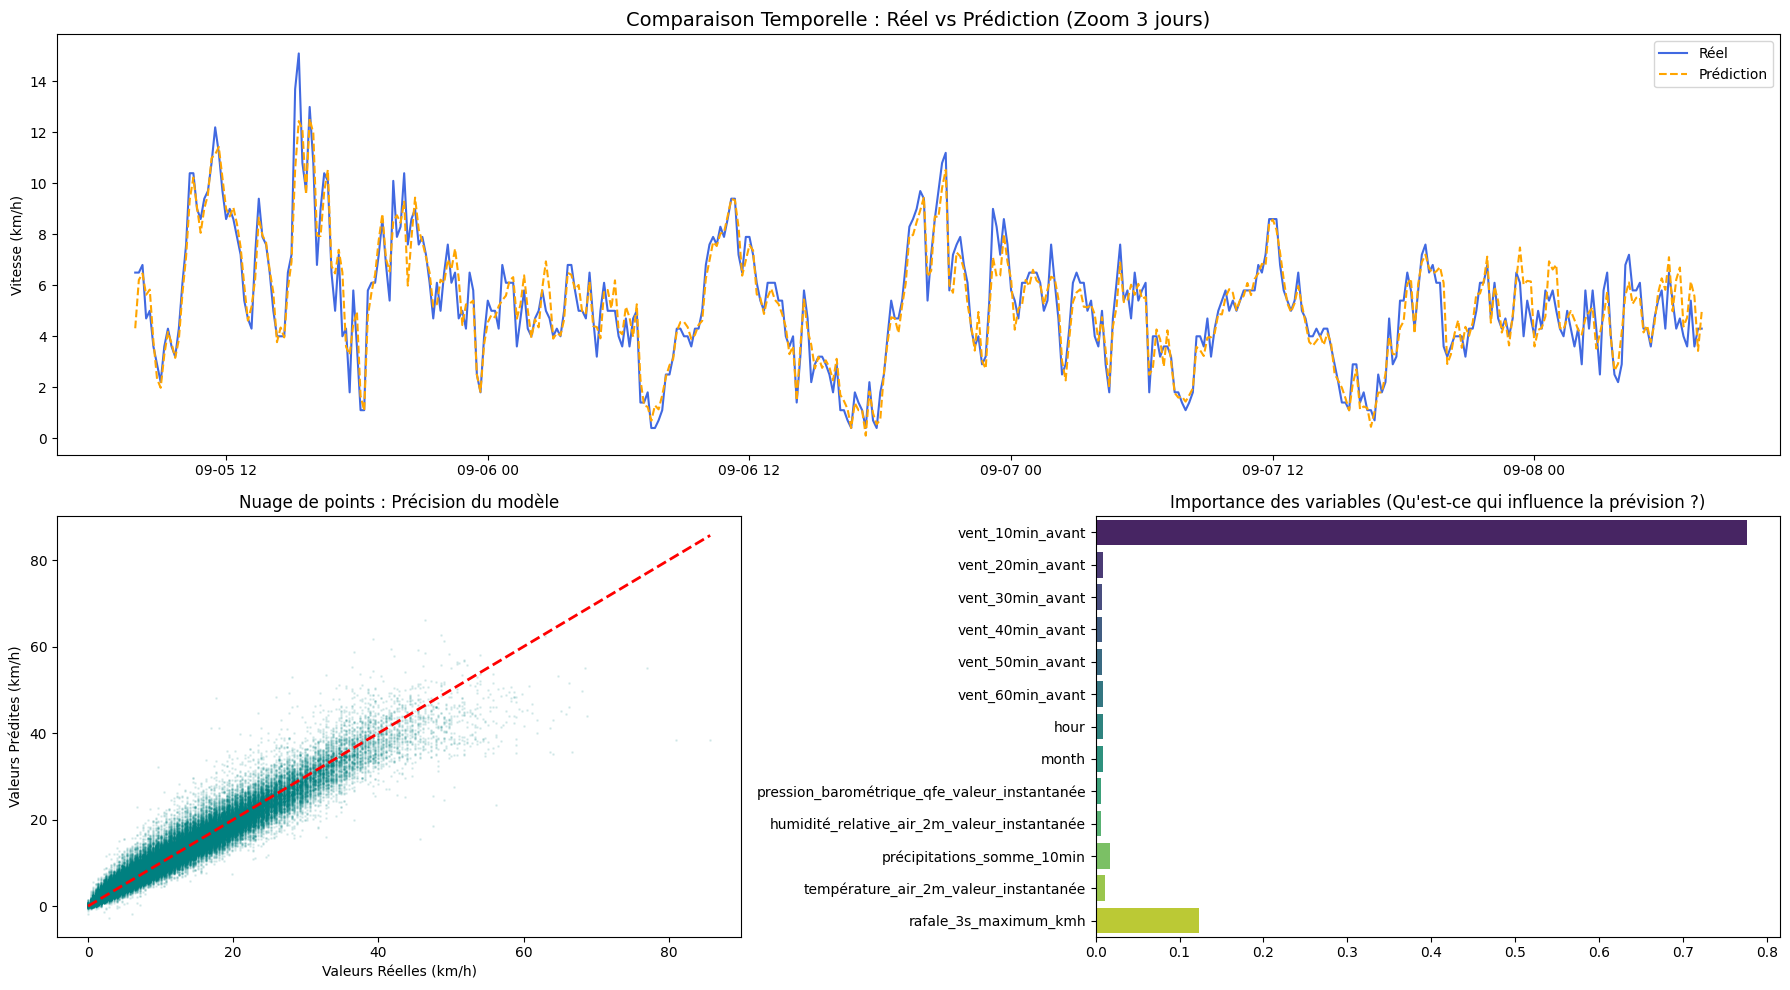

In [24]:
plt.figure(figsize=(18, 10))

# Graphique 1 : Zoom sur 72h (432 points de 10 min)
plt.subplot(2, 1, 1)
plt.plot(test_df['horodatage_référence'].iloc[:432], y_test.iloc[:432], label='Réel', color='royalblue', lw=1.5)
plt.plot(test_df['horodatage_référence'].iloc[:432], y_pred[:432], label='Prédiction', color='orange', linestyle='--', lw=1.5)
plt.title("Comparaison Temporelle : Réel vs Prédiction (Zoom 3 jours)", fontsize=14)
plt.legend()
plt.ylabel("Vitesse (km/h)")

# Graphique 2 : Corrélation (Nuage de points)
plt.subplot(2, 2, 3)
plt.scatter(y_test, y_pred, alpha=0.1, s=1, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Valeurs Réelles (km/h)")
plt.ylabel("Valeurs Prédites (km/h)")
plt.title("Nuage de points : Précision du modèle")

# Graphique 3 : Importance des variables
plt.subplot(2, 2, 4)
importances = model.feature_importances_
sns.barplot(x=importances, y=features, palette='viridis')
plt.title("Importance des variables (Qu'est-ce qui influence la prévision ?)")

plt.tight_layout()
plt.show()